#  Notebook 07 — Executive Dashboard
## Goal: Summarize entire business in one powerful visualization
**Audience:** CEO / Senior Management
**Message:** Complete business health in 60 seconds

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

master = pd.read_csv("../data/processed/master_clean.csv")

date_cols = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    master[col]= pd.to_datetime(master[col], errors='coerce')

master['order_month'] = master['order_purchase_timestamp'].dt.to_period('M')

print(" DATA LOADED")
print(f" Shape: {master.shape[0]:,} rows x {master.shape[1]} columns")

 DATA LOADED
 Shape: 119,143 rows x 29 columns


## Question 1 Prepare All Data First

In [25]:
# KPI

total_revenue = master['payment_value'].sum()
total_orders = master['order_id'].nunique()
total_customers = master['customer_unique_id'].nunique()
avg_order_value = master.groupby('order_id')['payment_value'].sum().mean()
avg_review = master['review_score'].mean()

# MONTHLY REVENUE
monthly_revenue = master.groupby('order_month')['payment_value'].sum().reset_index()
monthly_revenue.columns=['month','revenue']
monthly_revenue['month']= monthly_revenue['month'].astype(str)

# TOP CATEGORIS
top_cat = master.groupby('product_category_name_english')['payment_value'].sum().reset_index()
top_cat.columns=['category', 'revenue']
top_cat = top_cat.sort_values('revenue', ascending=False).head(10)

# PAYMENT_TYPE
payment_counts = master.groupby('payment_type')['order_id'].nunique().reset_index()
payment_counts.columns =['payment_type','count']

# REVIEW SCORES
review_scores = master.groupby('review_score')['order_id'].nunique().reset_index()
review_scores.columns =['score','count']

# DELIVERY PERFORMANCE 
delivered = master[master['order_status'] =='delivered'].copy()
delivered['delivery_days'] = (
    delivered['order_delivered_customer_date'] -
    delivered['order_purchase_timestamp']
).dt.days
avg_delivery = delivered['delivery_days'].mean()

delivered['is_late'] = (
    delivered['order_delivered_customer_date'] >
    delivered['order_estimated_delivery_date']
)
late_pct = delivered['is_late'].mean() * 100

# TOP_STATES
top_states = master.groupby('customer_state')['payment_value'].sum().reset_index()
top_states.columns=['states','revenue']
top_states = top_states.sort_values('revenue', ascending=False).head(10)



print(" ALL data prepared !")
print(f" Total Revenue    : {total_revenue:,.0f}")
print(f" Total Orders     : {total_orders:,}")
print(f" Total Customers  : {total_customers:,}")
print(f" Avg Order Value  : {avg_order_value:,.2f}")
print(f" Avg Review       : {avg_review:.2f}")
print(f" Avg Delivery     : {avg_delivery:,.1f} days")
print(f" Late %           : {late_pct:.1f}%")

 ALL data prepared !
 Total Revenue    : 20,579,664
 Total Orders     : 99,441
 Total Customers  : 96,096
 Avg Order Value  : 206.95
 Avg Review       : 4.02
 Avg Delivery     : 12.0 days
 Late %           : 7.8%


## Question 2  Build the Dashboard

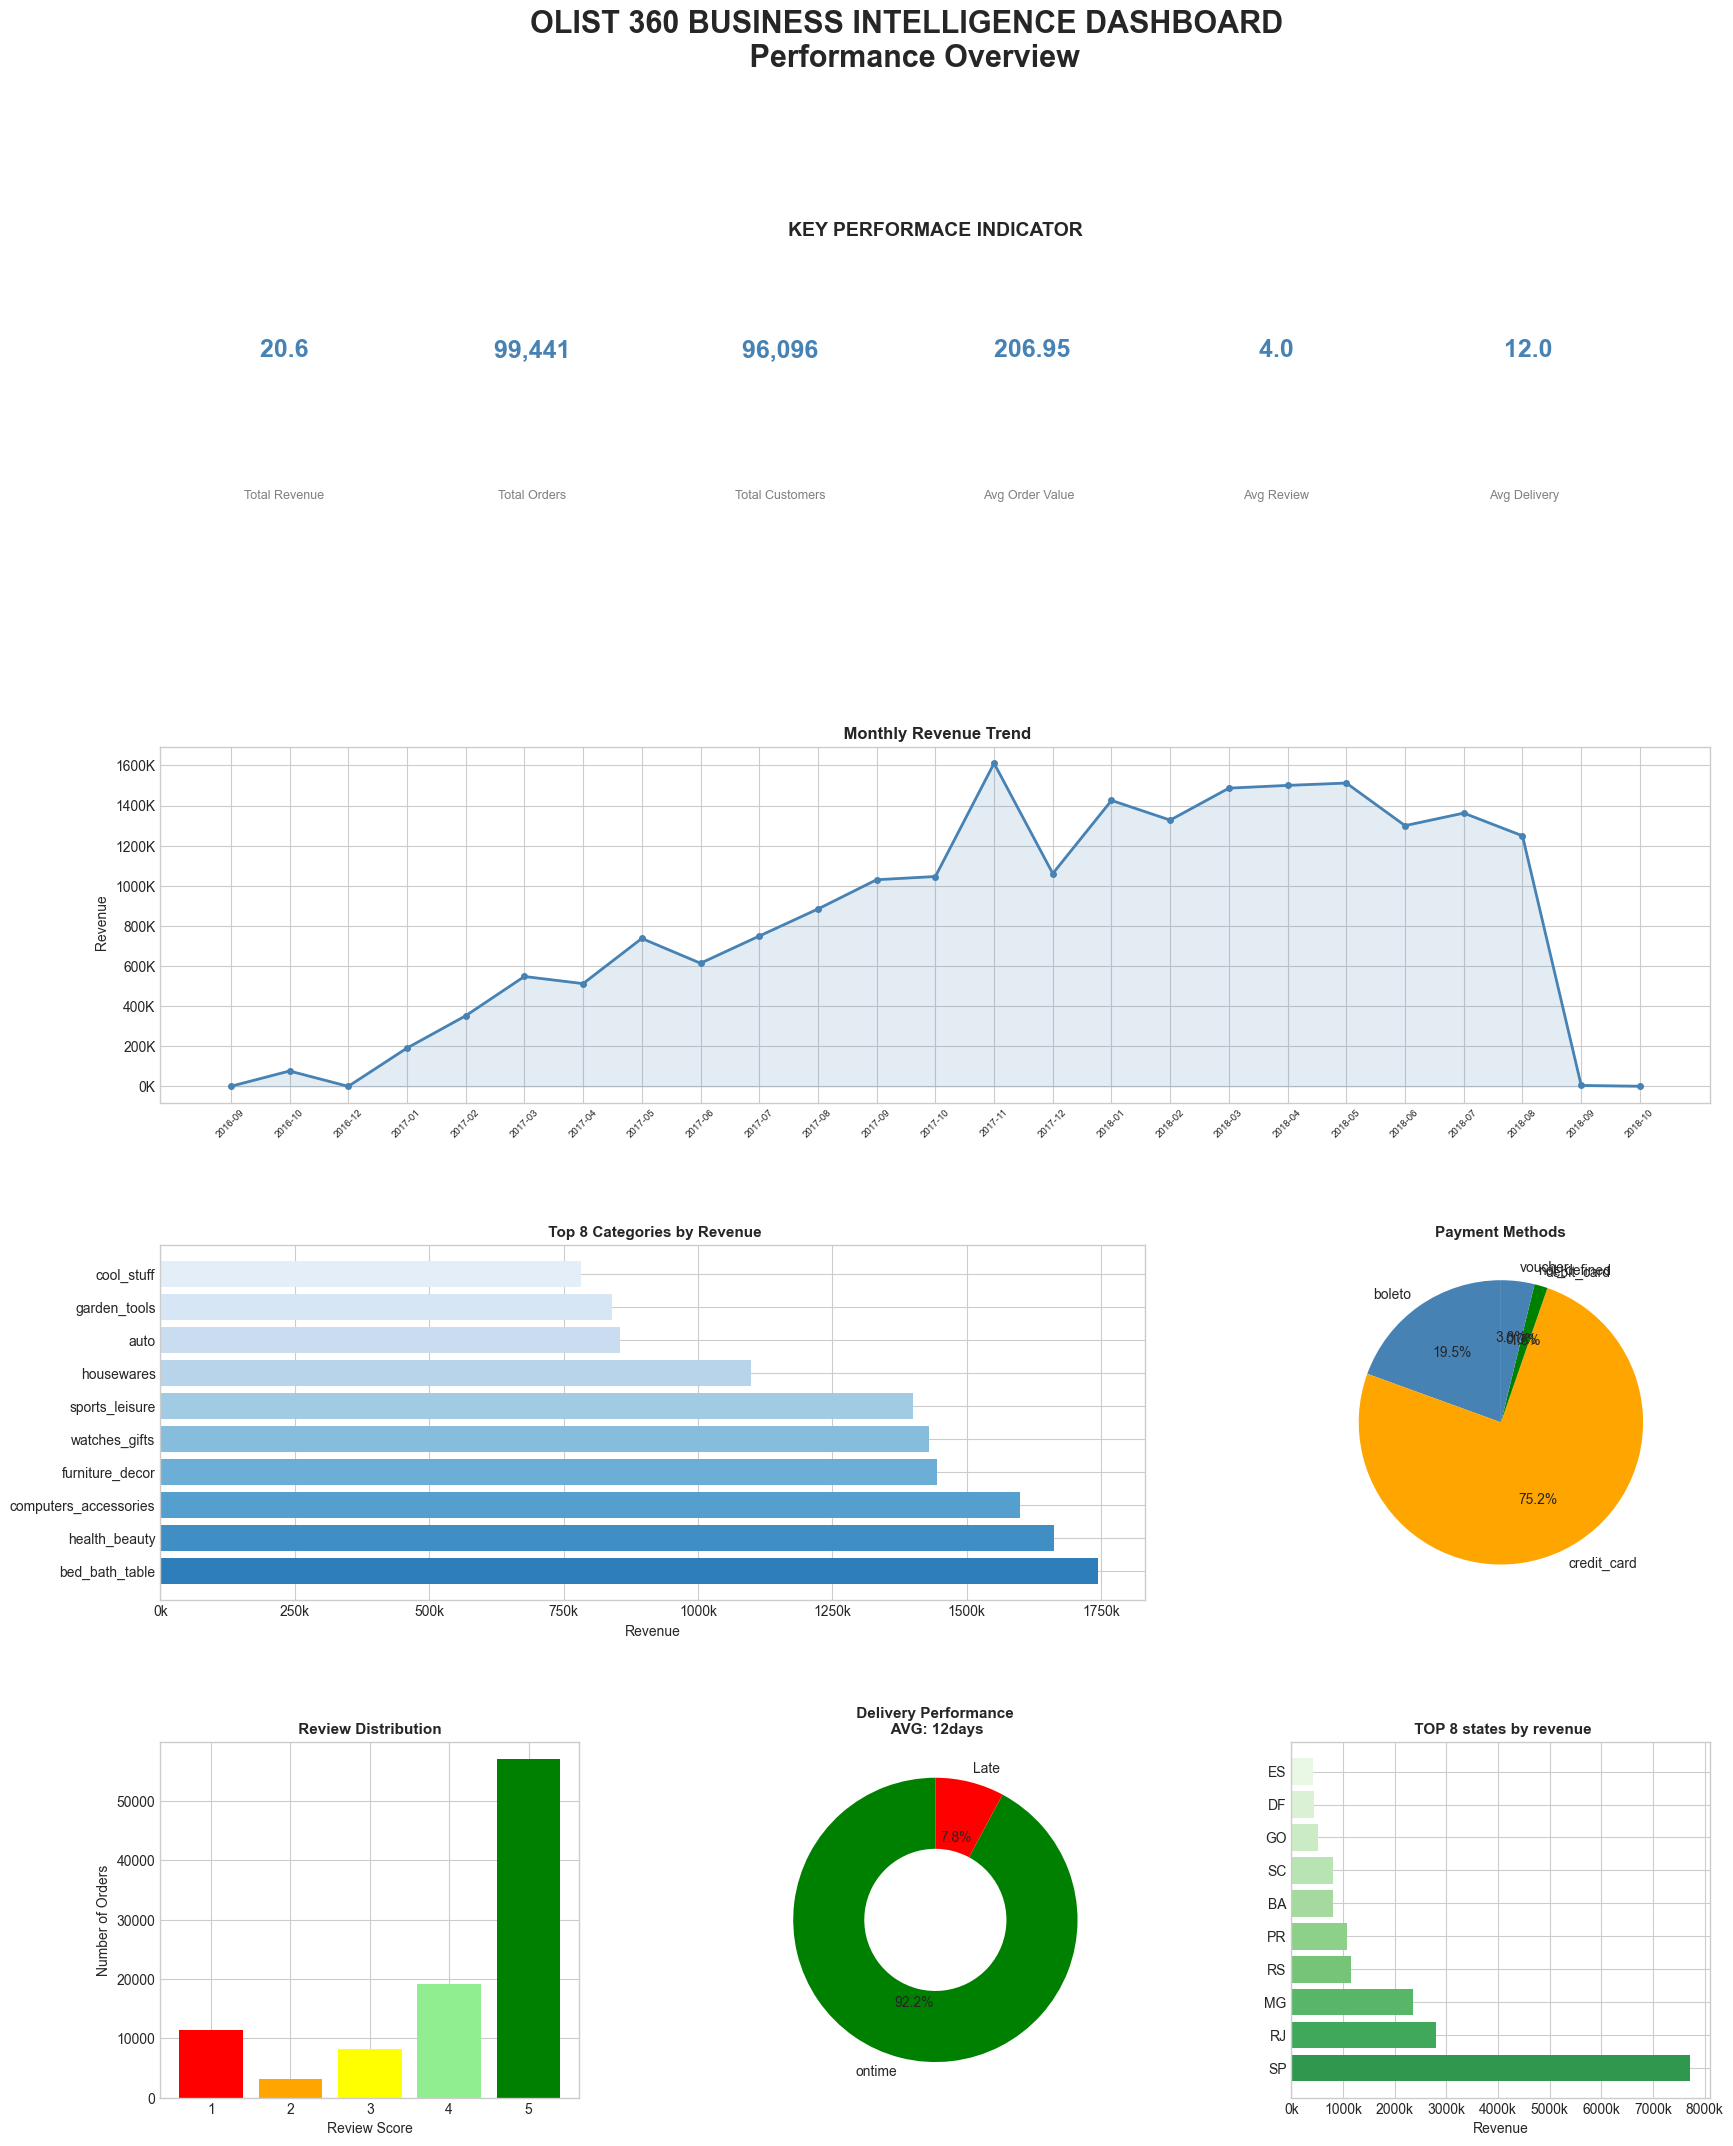

 Executive Dashboard saved!
Location: visuals/EXECUTIVE_DASHBOARD.png


In [67]:
# Set overall style
plt.style.use('seaborn-v0_8-whitegrid')

# Create large figure
fig = plt.figure(figsize=(20, 24))
fig.suptitle('OLIST 360 BUSINESS INTELLIGENCE DASHBOARD \n Performance Overview',
             fontsize=22, fontweight='bold', y=0.98)


gs = gridspec.GridSpec(4, 3, figure=fig,
                       hspace=0.4, wspace=0.35)


# PANEL 1 KPI CARDS
ax_kpi = fig.add_subplot(gs[0,:])
ax_kpi.axis('off')

kpis = [
    ('Total Revenue',   f" {total_revenue/1e6:.1f} "),
    ('Total Orders',    f" {total_orders:,} "),
    ('Total Customers', f" {total_customers:,} "),
    ('Avg Order Value', f" {avg_order_value:,.2f}"),
    ('Avg Review',      f" {avg_review:,.1f} "),
    ('Avg Delivery',    f" {avg_delivery:,.1f}")
]

for i, (label,value) in enumerate(kpis):
    x_pos =0.08 + i * 0.16
    ax_kpi.text(x_pos, 0.7, value, transform=ax_kpi.transAxes,
                fontsize=18, fontweight='bold',
                ha='center', color='steelblue')
    ax_kpi.text(x_pos, 0.3, label, transform=ax_kpi.transAxes,
                fontsize=9, ha='center', color='grey')

ax_kpi.set_title('KEY PERFORMACE INDICATOR',
                 fontsize=14, fontweight='bold', pad=10)



# MONTHLY REVENUE
ax1 = fig.add_subplot(gs[1, :])

ax1.plot(range(len(monthly_revenue)), monthly_revenue['revenue'],
         color='steelblue', linewidth=2, marker='o', markersize=4)
ax1.fill_between(range(len(monthly_revenue)), monthly_revenue['revenue'],
                 alpha=0.15, color='steelblue')
ax1.set_xticks(range(len(monthly_revenue)))
ax1.set_xticklabels(monthly_revenue['month'],rotation=45, fontsize=7)
ax1.set_title(' Monthly Revenue Trend', fontsize=12, fontweight='bold')
ax1.set_ylabel(' Revenue')
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1e3:.0f}K'))


# 3 & 4 Category and Payment

ax2 = fig.add_subplot(gs[2,0:2])
ax3 =fig.add_subplot(gs[2,2])

# TOP CATEGORIES

colors_cat = plt.cm.Blues_r(np.linspace(0.3,0.9, len(top_cat)))
bars= ax2.barh(top_cat['category'], top_cat['revenue'],color=colors_cat)
ax2.set_title(' Top 8 Categories by Revenue', fontsize=11, fontweight='bold')
ax2.set_xlabel('Revenue')
ax2.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1e3:.0f}k'))

colors_pay =['steelblue' ,'orange', 'green', 'red']
ax3.pie(payment_counts['count'],
        labels=payment_counts['payment_type'],
        colors=colors_pay,
        autopct='%1.1f%%',
        startangle=90)
ax3.set_title('Payment Methods', fontsize=11, fontweight='bold')

# 5 & 6 Reviews & Delivery
ax4= fig.add_subplot(gs[3,0])
ax5= fig.add_subplot(gs[3,1])
ax6= fig.add_subplot(gs[3,2])

# REVIEW DISTRIBUTION
rev_colors=['red', 'orange', 'yellow', 'lightgreen', 'green']
ax4.bar(review_scores['score'], review_scores['count'], color=rev_colors)
ax4.set_title(' Review Distribution ', fontsize=11, fontweight='bold')
ax4.set_xlabel('Review Score')
ax4.set_ylabel('Number of Orders')


# DELIVERY PERFORMANCE 
late_count = delivered['is_late'].sum()
ontime_count =len(delivered) - late_count
delivery_data = [ontime_count, late_count]
delivery_labels = ['ontime', 'Late']
delivery_colors = ['green', 'red']

wedges, texts, autotexts = ax5.pie(
    delivery_data,
    labels=delivery_labels,
    colors=delivery_colors,
    autopct= '%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.5)
)

ax5.set_title(f' Delivery Performance \n AVG: {avg_delivery:.0f}days',
              fontsize=11, fontweight='bold')


# TOP STATES
colors_states = plt.cm.Greens_r(np.linspace(0.3, 0.9, len(top_states)))
ax6.barh(top_states['states'], top_states['revenue'], color=colors_states)
ax6.set_title(' TOP 8 states by revenue', fontsize=11, fontweight='bold')
ax6.set_xlabel('Revenue')
ax6.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1e3:.0f}k'))


# ── SAVE AND SHOW DASHBOARD ───────────────────
plt.savefig('../visuals/EXECUTIVE_DASHBOARD.png',
            dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()

print(" Executive Dashboard saved!")
print("Location: visuals/EXECUTIVE_DASHBOARD.png")

## Question 3  Business Summary Cell

In [70]:
# ── EXECUTIVE SUMMARY ─────────────────────────
print("=" * 65)
print(" OLIST EXECUTIVE SUMMARY — KEY FINDINGS")
print("=" * 65)
print(f"""
BUSINESS SCALE
  Total Revenue     :  {total_revenue:>15,.0f}
  Total Orders      : {total_orders:>18,}
  Total Customers   : {total_customers:>18,}
  Avg Order Value   :  {avg_order_value:>15,.2f}

CUSTOMER SATISFACTION
  Average Review    : {avg_review:>18.2f} / 5.00
  Late Deliveries   : {late_pct:>17.1f}% of orders
  Avg Delivery Time : {avg_delivery:>14.1f} days

TOP PERFORMANCE
  Best State        : {top_states.iloc[0]['states']:>18}
  Best Category     : {top_cat.iloc[0]['category']:>18}
  Top Payment       : {payment_counts.sort_values('count',ascending=False).iloc[0]['payment_type']:>18}

KEY RECOMMENDATIONS
  1. November is peak month — prepare inventory 2 months ahead
  2. {late_pct:.0f}% late delivery rate needs logistics investment
  3. Focus retention on Champion customer segment
  4. Top 3 states drive majority of revenue — protect these markets
  5. Promote hidden gem categories with high reviews but low sales
""")
print("=" * 65)

 OLIST EXECUTIVE SUMMARY — KEY FINDINGS

BUSINESS SCALE
  Total Revenue     :       20,579,664
  Total Orders      :             99,441
  Total Customers   :             96,096
  Avg Order Value   :           206.95

CUSTOMER SATISFACTION
  Average Review    :               4.02 / 5.00
  Late Deliveries   :               7.8% of orders
  Avg Delivery Time :           12.0 days

TOP PERFORMANCE
  Best State        :                 SP
  Best Category     :     bed_bath_table
  Top Payment       :        credit_card

KEY RECOMMENDATIONS
  1. November is peak month — prepare inventory 2 months ahead
  2. 8% late delivery rate needs logistics investment
  3. Focus retention on Champion customer segment
  4. Top 3 states drive majority of revenue — protect these markets
  5. Promote hidden gem categories with high reviews but low sales

